## 1. Setup  

In [1]:
from google.colab import files
import os

print('Please upload: PGCB_date_power_demand.csv, weather_data.csv, economic_full_1.csv')
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Please upload: PGCB_date_power_demand.csv, weather_data.csv, economic_full_1.csv


Saving economic_full_1.csv to economic_full_1.csv
Saving PGCB_date_power_demand.csv to PGCB_date_power_demand.csv
Saving weather_data.csv to weather_data.csv
User uploaded file "economic_full_1.csv" with length 622299 bytes
User uploaded file "PGCB_date_power_demand.csv" with length 6943918 bytes
User uploaded file "weather_data.csv" with length 5649844 bytes


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

PGCB_PATH    = 'PGCB_date_power_demand.csv'
WEATHER_PATH = 'weather_data.csv'
ECON_PATH    = 'economic_full_1.csv'


## 2. Load Datasets

Three sources are loaded: PGCB hourly power-grid records, Open-Meteo hourly weather data, and World Bank economic indicators for Bangladesh.

In [3]:
pgcb    = pd.read_csv(PGCB_PATH,    parse_dates=['datetime'])
weather = pd.read_csv(WEATHER_PATH,  skiprows=3, parse_dates=['time'])
weather.columns = [col.split(' ')[0] for col in weather.columns]
econ    = pd.read_csv(ECON_PATH)

print(f'PGCB    : {pgcb.shape}')
print(f'Weather : {weather.shape}')
print(f'Economic: {econ.shape}')

PGCB    : (92650, 15)
Weather : (107304, 10)
Economic: (1516, 69)


## 3. Exploratory Data Analysis

### 3.1 PGCB  Data Types & Missing Values

In [4]:

print("="*60)
print("PGCB -- Data Types & Non-Null Counts")
print("="*60)
pgcb.info()
# Missing values summary table
missing = pgcb.isnull().sum().reset_index()
missing.columns = ['Column', 'Missing']
missing['Pct_Missing'] = (missing['Missing'] / len(pgcb) * 100).round(2)
missing = missing.sort_values('Missing', ascending=False)
print("\n", missing.to_string(index=False))


PGCB -- Data Types & Non-Null Counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              92650 non-null  datetime64[ns]
 1   generation_mw         92650 non-null  float64       
 2   demand_mw             92650 non-null  int64         
 3   load_shedding         92650 non-null  int64         
 4   gas                   92650 non-null  int64         
 5   liquid_fuel           92650 non-null  int64         
 6   coal                  92650 non-null  int64         
 7   hydro                 92650 non-null  int64         
 8   solar                 70517 non-null  float64       
 9   wind                  18676 non-null  float64       
 10  india_bheramara_hvdc  92650 non-null  int64         
 11  india_tripura         92650 non-null  int64         
 12  india_adani           7338 non-null  

### 3.2 Missing Values  Bar Chart

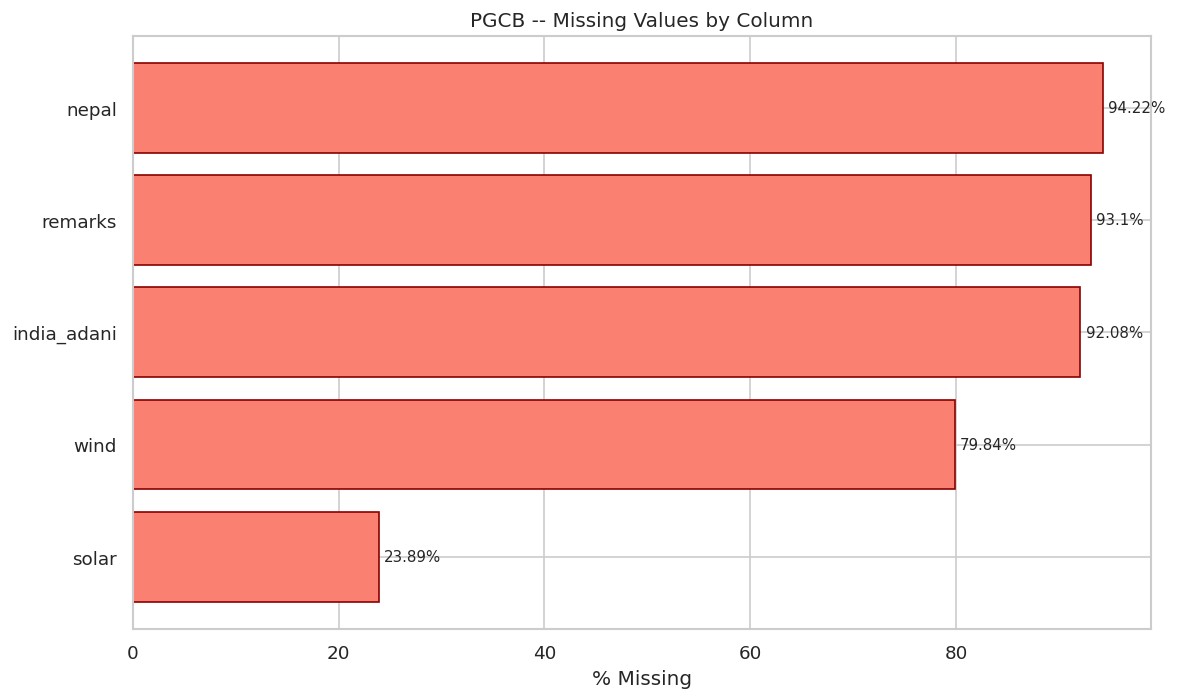

In [5]:

miss_cols = missing[missing['Missing'] > 0].sort_values('Missing', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(miss_cols['Column'], miss_cols['Pct_Missing'], color='salmon', edgecolor='darkred')
ax.set_xlabel('% Missing')
ax.set_title('PGCB -- Missing Values by Column')
for bar, val in zip(bars, miss_cols['Pct_Missing']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=9)
plt.tight_layout(); plt.show()


### 3.3 Outlier Detection & Descriptive Statistics & IQR Flagging

1.   List item
2.   List item



In [6]:

print("PGCB -- Descriptive Statistics (numeric columns)")
print(pgcb.describe().T.to_string())

# 1.5xIQR outlier detection on demand_mw
Q1 = pgcb['demand_mw'].quantile(0.25)
Q3 = pgcb['demand_mw'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = pgcb[(pgcb['demand_mw'] < lower_bound) | (pgcb['demand_mw'] > upper_bound)]

print(f"\ndemand_mw IQR Analysis:")
print(f"  Q1={Q1:.0f}, Q3={Q3:.0f}, IQR={IQR:.0f}")
print(f"  Lower bound={lower_bound:.0f}, Upper bound={upper_bound:.0f}")
print(f"  Outliers detected: {len(outliers)}")


PGCB -- Descriptive Statistics (numeric columns)
                        count                           mean                  min                  25%                  50%                  75%                  max            std
datetime                92650  2020-05-17 03:52:07.609282304  2015-04-19 00:00:00  2017-10-31 06:15:00  2020-05-21 15:30:00  2022-12-03 18:22:30  2025-06-17 12:00:00            NaN
generation_mw         92650.0                    9429.376471                 73.0             6814.775               8412.0              10556.0           64526500.0  211975.938358
demand_mw             92650.0                    8819.646044                  6.0              6812.25               8422.0              10633.0             156050.0    2772.150108
load_shedding         92650.0                      81.470405                  0.0                  0.0                  0.0                  0.0              65359.0     442.757182
gas                   92650.0                 

### 3.4 Demand Distribution & Histogram & Boxplot

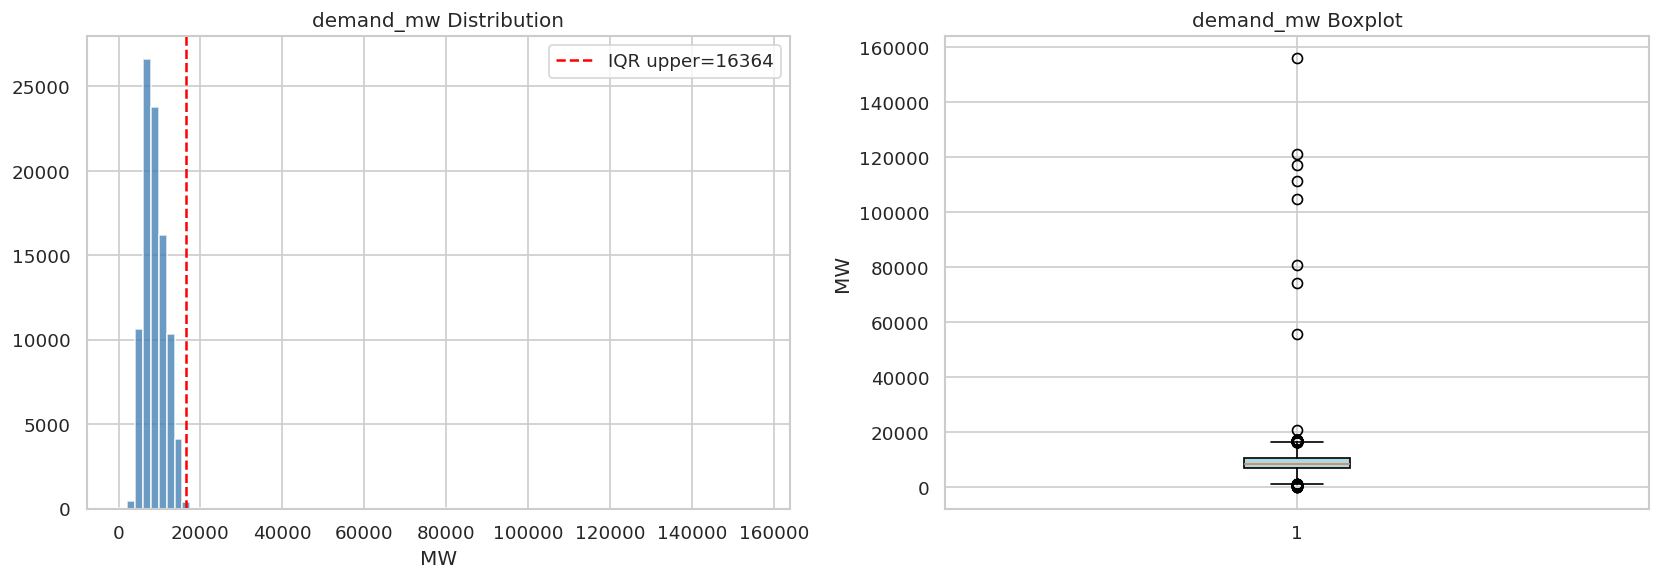

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(pgcb['demand_mw'].dropna(), bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(upper_bound, color='red', ls='--', label=f'IQR upper={upper_bound:.0f}')
axes[0].set_title('demand_mw Distribution')
axes[0].set_xlabel('MW'); axes[0].legend()

# Boxplot
axes[1].boxplot(pgcb['demand_mw'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('demand_mw Boxplot')
axes[1].set_ylabel('MW')

plt.tight_layout(); plt.show()


### 3.5 Full Time Series & Daily Resampled Trend

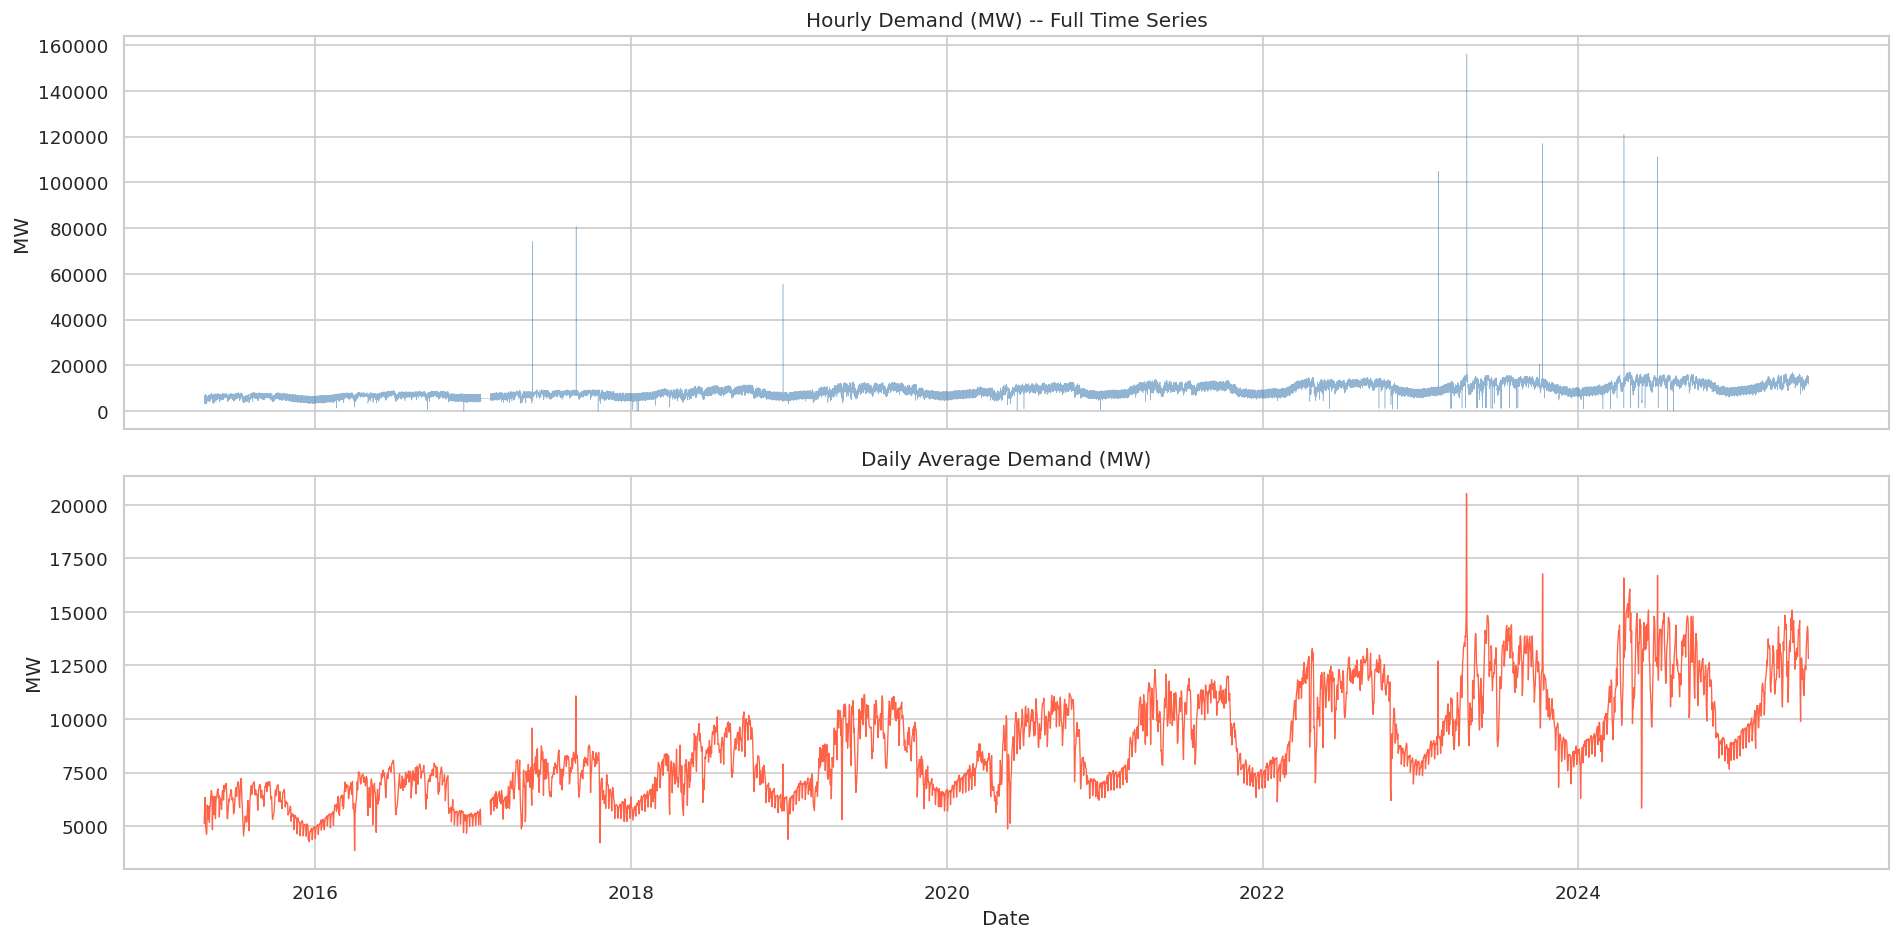

In [8]:

pgcb_sorted = pgcb.sort_values('datetime')

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Raw hourly
axes[0].plot(pgcb_sorted['datetime'], pgcb_sorted['demand_mw'], lw=0.3, alpha=0.6, color='steelblue')
axes[0].set_title('Hourly Demand (MW) -- Full Time Series')
axes[0].set_ylabel('MW')

# Daily resampled
daily = pgcb_sorted.set_index('datetime')['demand_mw'].resample('D').mean()
axes[1].plot(daily.index, daily.values, lw=0.8, color='tomato')
axes[1].set_title('Daily Average Demand (MW)')
axes[1].set_ylabel('MW'); axes[1].set_xlabel('Date')

plt.tight_layout(); plt.show()


### 3.6 Duplicate Timestamps & Frequency Analysis

In [9]:

# Duplicate timestamps (same datetime, different demand readings)
dup_mask = pgcb_sorted.duplicated(subset='datetime', keep=False)
dup_timestamps = pgcb_sorted[dup_mask]
print(f"Duplicate timestamps: {dup_timestamps['datetime'].nunique()} unique datetimes with {len(dup_timestamps)} total rows")
if len(dup_timestamps) > 0:
    print(dup_timestamps[['datetime','demand_mw']].head(10).to_string(index=False))

# Mixed frequency: rows with :30 minute timestamps
has_30min = pgcb_sorted['datetime'].dt.minute == 30
print(f"\nRows at :30 minute mark: {has_30min.sum():,}")
print(f"Rows at :00 minute mark: {(~has_30min).sum():,}")
print("-> Dataset has mixed hourly / half-hourly frequency. Will resample to 1H mean.")


Duplicate timestamps: 381 unique datetimes with 813 total rows
           datetime  demand_mw
2015-04-22 21:00:00       5811
2015-04-22 21:00:00       5368
2015-04-23 00:00:00       5726
2015-04-23 00:00:00       3976
2015-04-27 00:00:00       5236
2015-04-27 00:00:00       4800
2015-04-27 00:00:00       5459
2015-04-30 00:00:00       5809
2015-04-30 00:00:00       6065
2015-04-30 00:00:00       6889

Rows at :30 minute mark: 4,181
Rows at :00 minute mark: 88,469
-> Dataset has mixed hourly / half-hourly frequency. Will resample to 1H mean.


### 3.7 Seasonality â€” Hour, Day of Week, Month

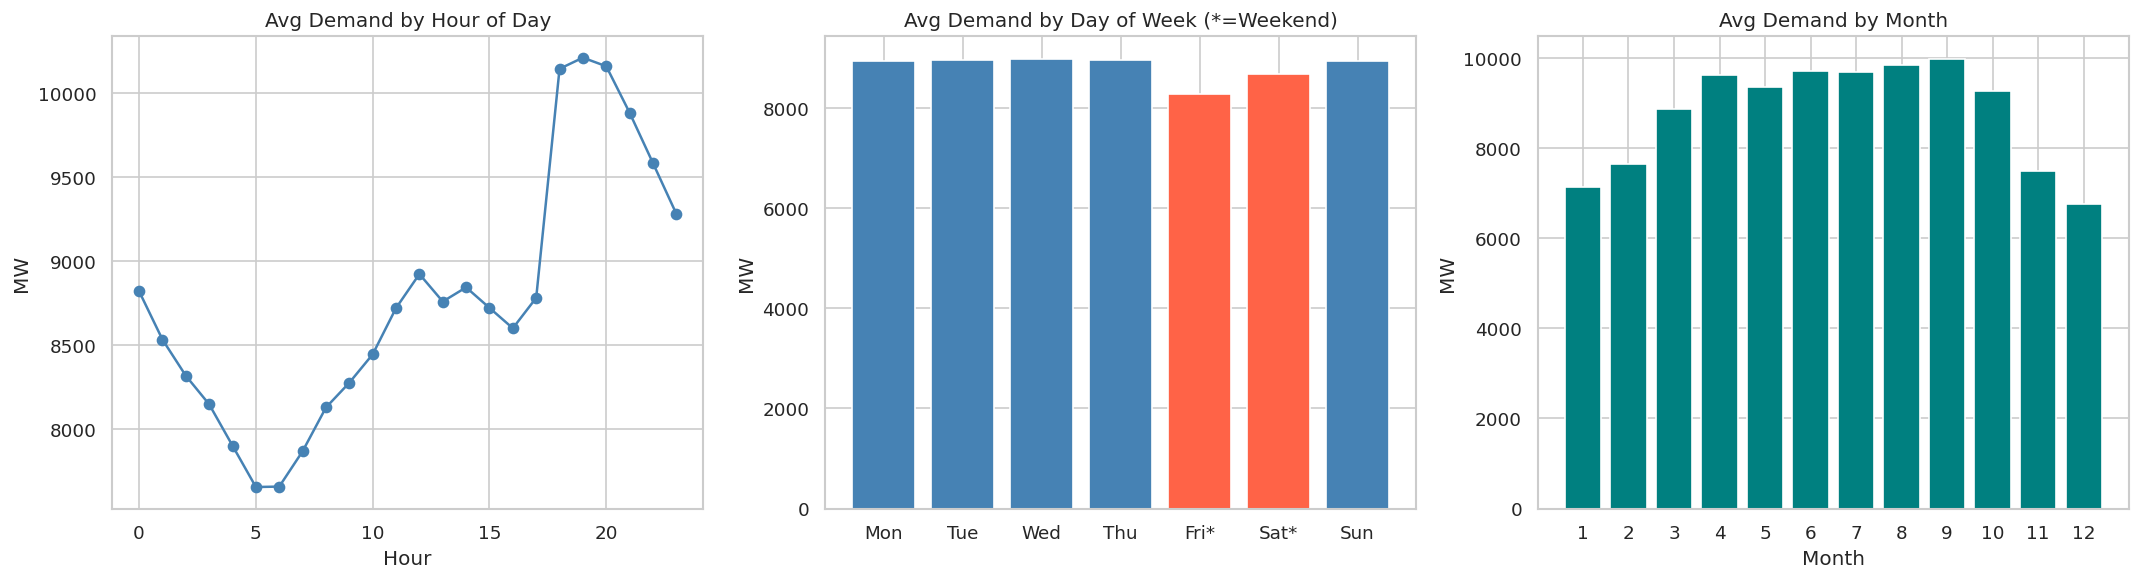

In [10]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# By hour of day
hourly_avg = pgcb_sorted.groupby(pgcb_sorted['datetime'].dt.hour)['demand_mw'].mean()
axes[0].plot(hourly_avg.index, hourly_avg.values, marker='o', color='steelblue')
axes[0].set_title('Avg Demand by Hour of Day'); axes[0].set_xlabel('Hour'); axes[0].set_ylabel('MW')

# By day of week (Bangladesh: Fri=4, Sat=5 are weekend)
dow_avg = pgcb_sorted.groupby(pgcb_sorted['datetime'].dt.dayofweek)['demand_mw'].mean()
day_labels = ['Mon','Tue','Wed','Thu','Fri*','Sat*','Sun']
colors = ['steelblue']*4 + ['tomato','tomato'] + ['steelblue']
axes[1].bar(dow_avg.index, dow_avg.values, color=colors, edgecolor='white')
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(day_labels)
axes[1].set_title('Avg Demand by Day of Week (*=Weekend)'); axes[1].set_ylabel('MW')

# By month
monthly_avg = pgcb_sorted.groupby(pgcb_sorted['datetime'].dt.month)['demand_mw'].mean()
axes[2].bar(monthly_avg.index, monthly_avg.values, color='teal', edgecolor='white')
axes[2].set_title('Avg Demand by Month'); axes[2].set_xlabel('Month'); axes[2].set_ylabel('MW')
axes[2].set_xticks(range(1,13))

plt.tight_layout(); plt.show()


### 3.8 Year-wise Demand Growth

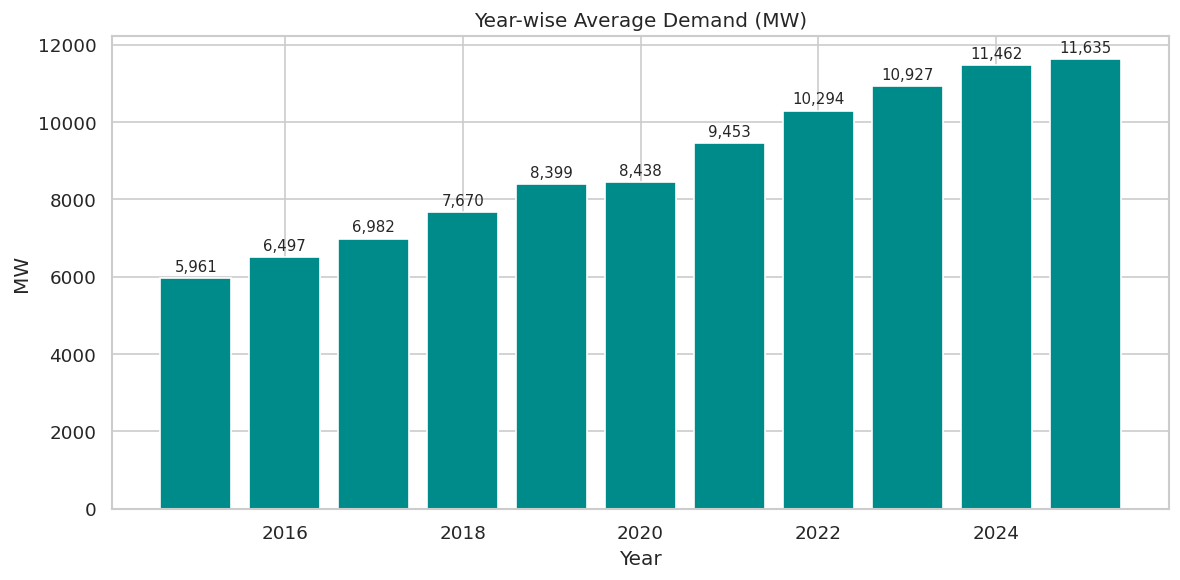

Growth: 5,961 MW (2015) -> 11,635 MW (2025)


In [11]:

yearly_avg = pgcb_sorted.groupby(pgcb_sorted['datetime'].dt.year)['demand_mw'].mean()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(yearly_avg.index, yearly_avg.values, color='darkcyan', edgecolor='white')
for bar, val in zip(bars, yearly_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f'{val:,.0f}',
            ha='center', va='bottom', fontsize=9)
ax.set_title('Year-wise Average Demand (MW)')
ax.set_xlabel('Year'); ax.set_ylabel('MW')
plt.tight_layout(); plt.show()
print(f"Growth: {yearly_avg.iloc[0]:,.0f} MW ({yearly_avg.index[0]}) -> {yearly_avg.iloc[-1]:,.0f} MW ({yearly_avg.index[-1]})")


### 3.9 Generation vs Demand Gap & Load Shedding

Rows removed as outliers: 9


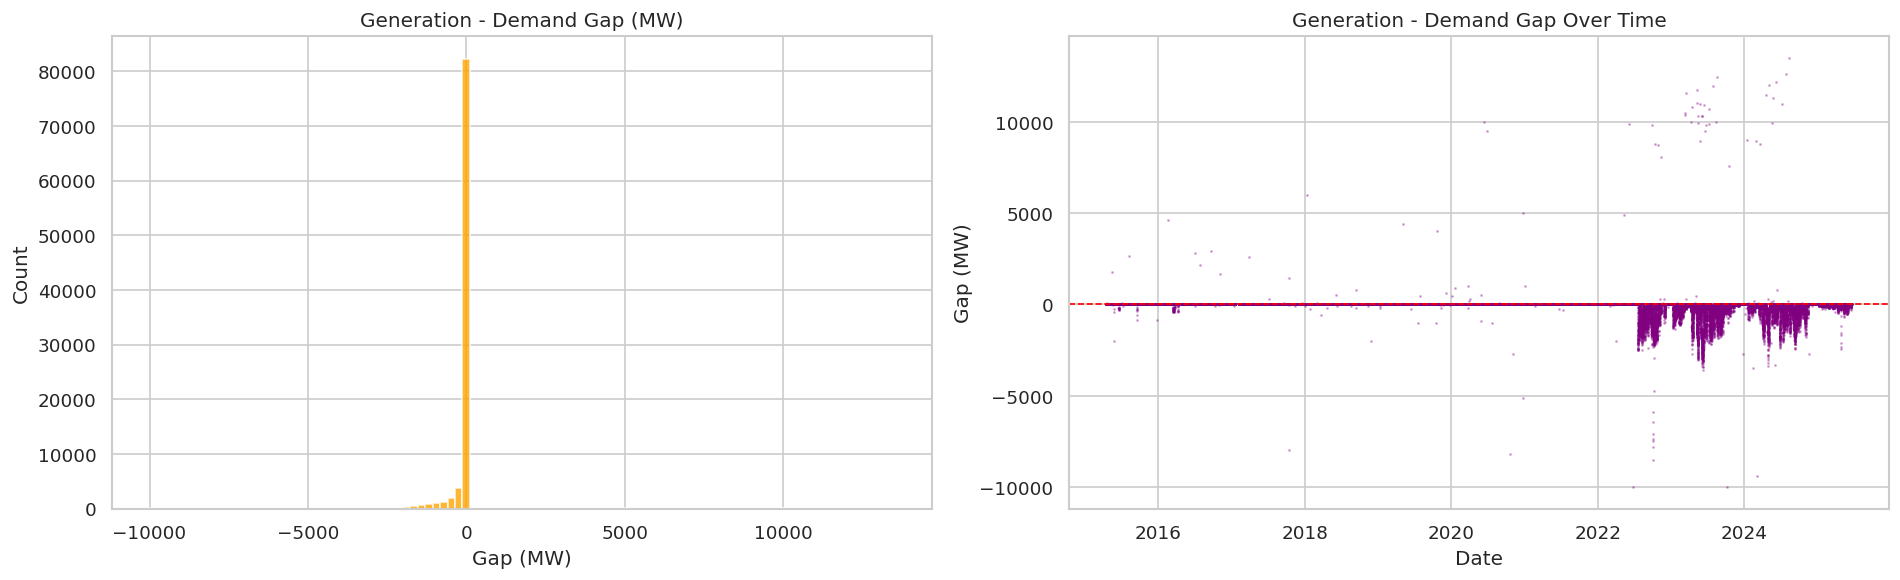

Gap stats:  min=-10,000  max=13,507  mean=-79
Extreme negative gaps (< -10,000 MW): 0 rows -- likely data errors

load_shedding -- non-null: 92,650, mean=81.5 MW


In [12]:

pgcb_sorted['gap_mw'] = pgcb_sorted['generation_mw'] - pgcb_sorted['demand_mw']

# Filter out data entry errors in BOTH generation and demand columns
# Bangladesh grid physically cannot exceed ~25,000 MW
clean = pgcb_sorted[
    (pgcb_sorted['generation_mw'] < 25_000) &
    (pgcb_sorted['demand_mw'] < 25_000)
].copy()
print(f"Rows removed as outliers: {len(pgcb_sorted) - len(clean)}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(clean['gap_mw'].dropna(), bins=100, color='orange', edgecolor='white', alpha=0.8)
axes[0].set_title('Generation - Demand Gap (MW)')
axes[0].set_xlabel('Gap (MW)'); axes[0].set_ylabel('Count')

axes[1].scatter(clean['datetime'], clean['gap_mw'], s=0.5, alpha=0.3, color='purple')
axes[1].axhline(0, color='red', ls='--', lw=1)
axes[1].set_title('Generation - Demand Gap Over Time')
axes[1].set_xlabel('Date'); axes[1].set_ylabel('Gap (MW)')

plt.tight_layout(); plt.show()

print(f"Gap stats:  min={clean['gap_mw'].min():,.0f}  max={clean['gap_mw'].max():,.0f}  "
      f"mean={clean['gap_mw'].mean():,.0f}")
extreme_neg = clean[clean['gap_mw'] < -10000]
print(f"Extreme negative gaps (< -10,000 MW): {len(extreme_neg)} rows -- likely data errors")

print(f"\nload_shedding -- non-null: {pgcb_sorted['load_shedding'].notna().sum():,}, "
      f"mean={pgcb_sorted['load_shedding'].mean():.1f} MW")

### 3.10 Energy Source Mix Over Time

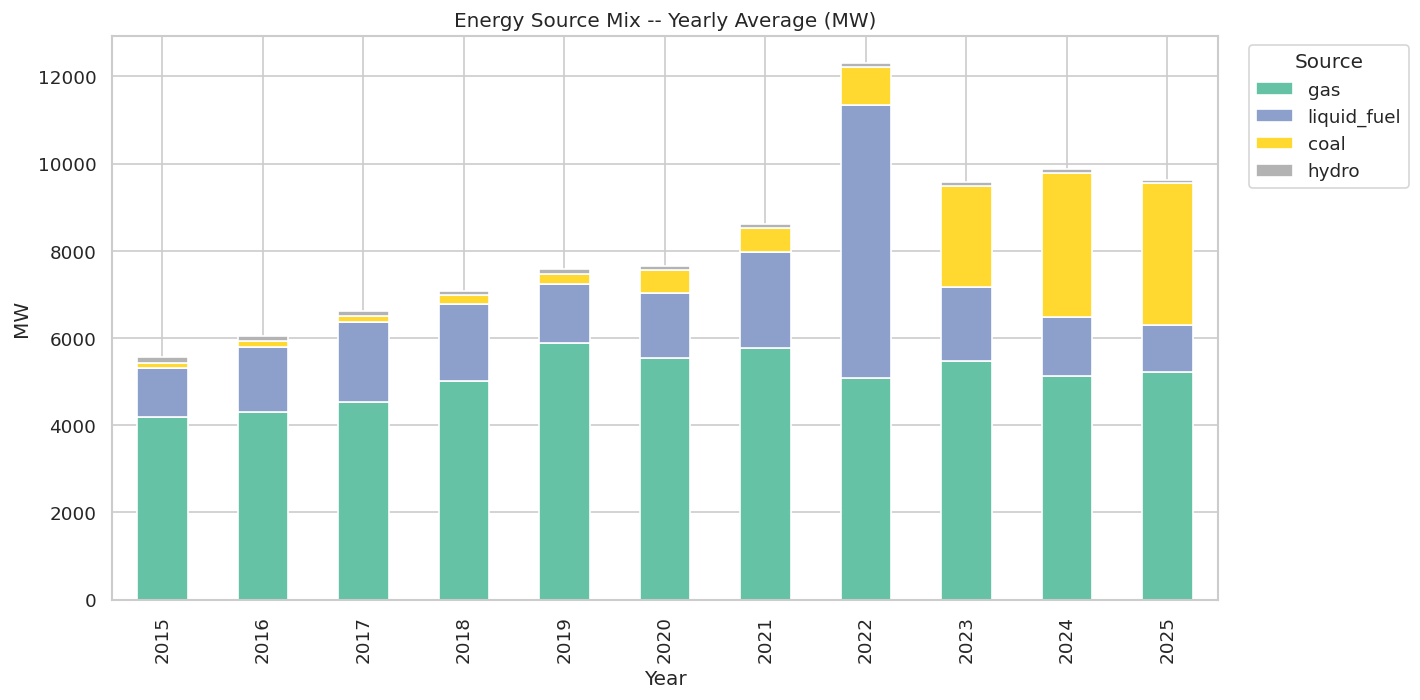

In [13]:

sources = ['gas', 'liquid_fuel', 'coal', 'hydro']
yearly_sources = pgcb_sorted.groupby(pgcb_sorted['datetime'].dt.year)[sources].mean()

fig, ax = plt.subplots(figsize=(12, 6))
yearly_sources.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='white')
ax.set_title('Energy Source Mix -- Yearly Average (MW)')
ax.set_xlabel('Year'); ax.set_ylabel('MW')
ax.legend(title='Source', bbox_to_anchor=(1.02, 1))
plt.tight_layout(); plt.show()


### 3.11 Weather â€” Correlation Heatmap & Monthly Temperature Trend

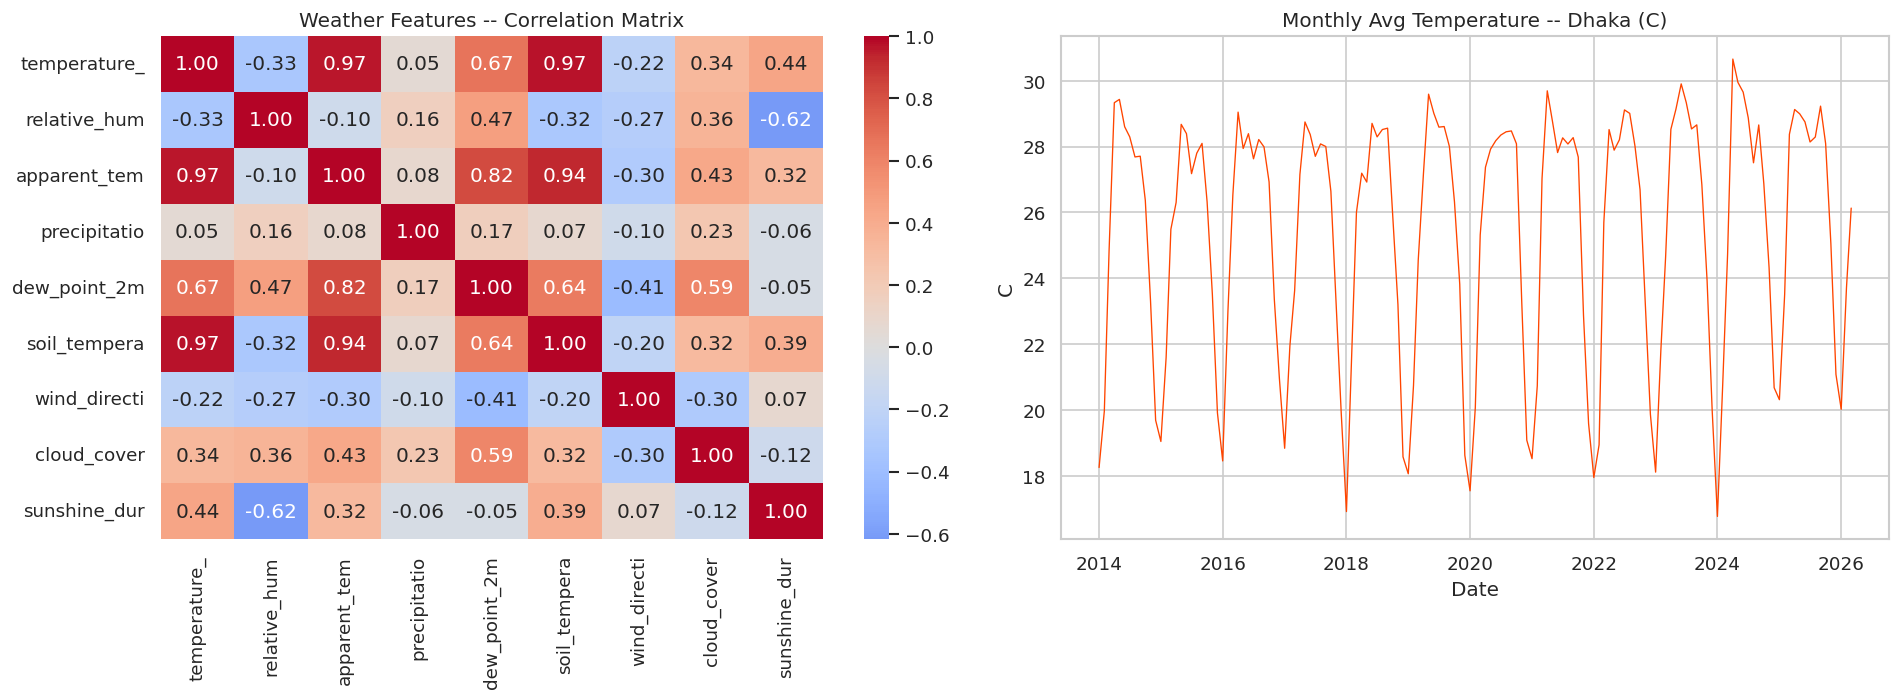

In [14]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation heatmap of weather features
weather_numeric = weather.select_dtypes(include=[np.number])
corr = weather_numeric.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0],
            xticklabels=[c[:12] for c in corr.columns],
            yticklabels=[c[:12] for c in corr.columns])
axes[0].set_title('Weather Features -- Correlation Matrix')

# Monthly temperature trend
weather['month_period'] = weather['time'].dt.to_period('M')
monthly_temp = weather.groupby('month_period')['temperature_2m'].mean()
axes[1].plot(monthly_temp.index.to_timestamp(), monthly_temp.values, lw=0.8, color='orangered')
axes[1].set_title('Monthly Avg Temperature -- Dhaka (C)')
axes[1].set_xlabel('Date'); axes[1].set_ylabel('C')

plt.tight_layout(); plt.show()


### 3.12 Economic Indicators â€” Missingness Map & Relevant Selection

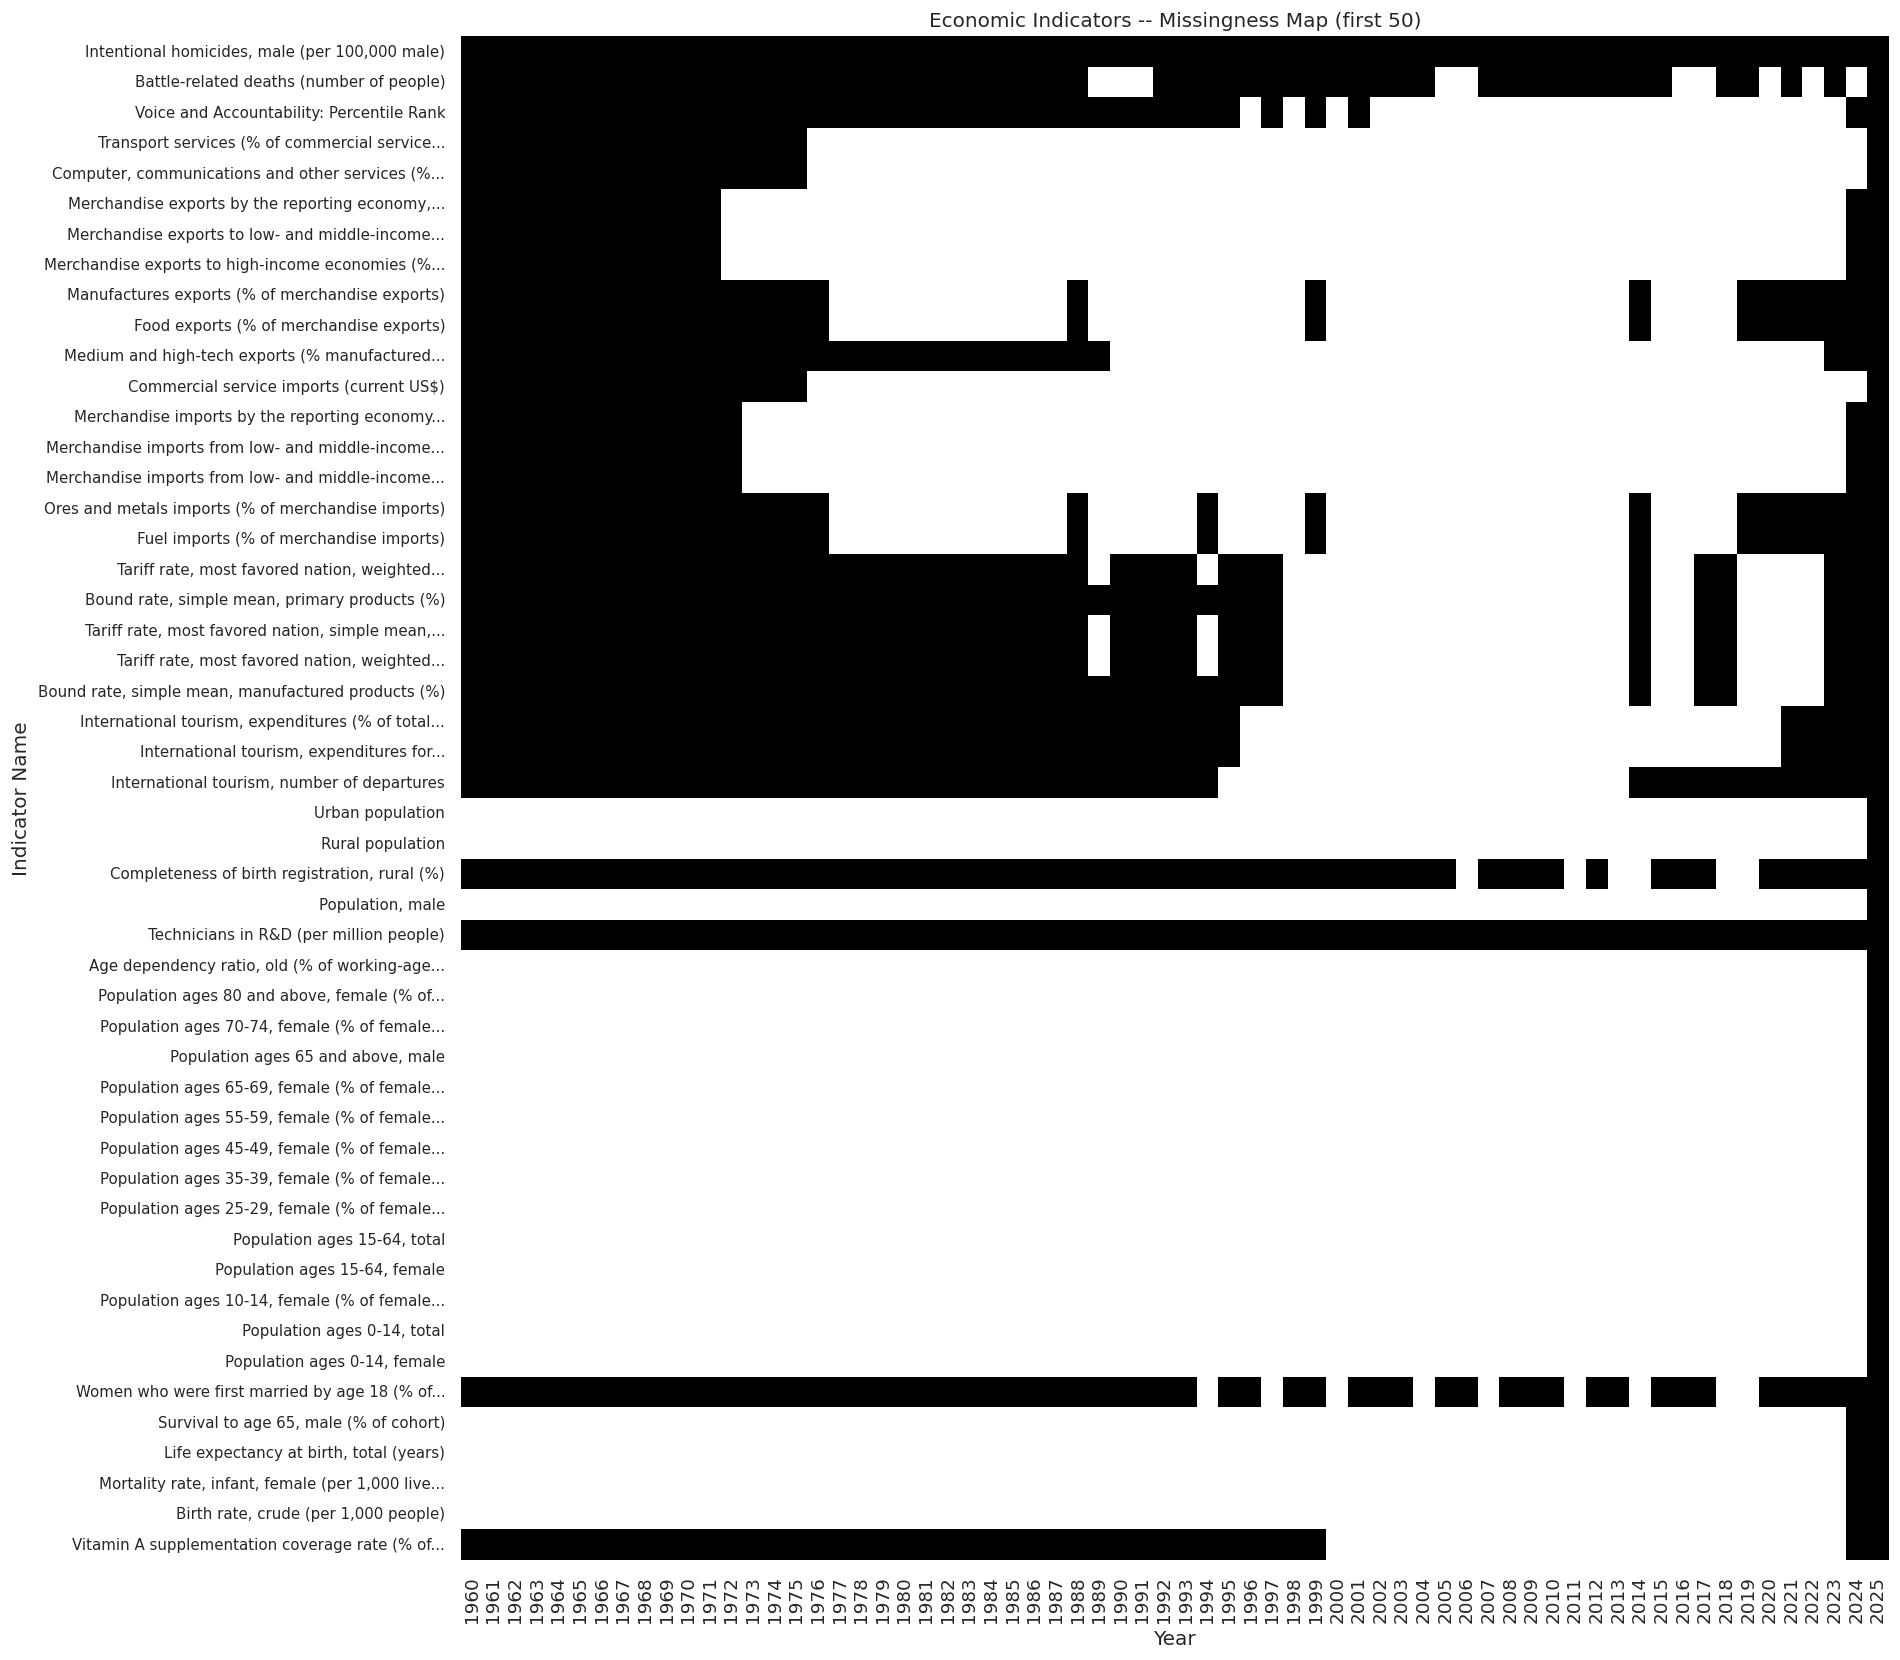

Indicator coverage: min=0, max=66, median=25 years

Relevant indicators found (energy/GDP/population): 382
                                               Indicator Name
                                             Urban population
                                             Rural population
                                             Population, male
      Age dependency ratio, old (% of working-age population)
Population ages 80 and above, female (% of female population)
       Population ages 70-74, female (% of female population)
                           Population ages 65 and above, male
       Population ages 65-69, female (% of female population)
       Population ages 55-59, female (% of female population)
       Population ages 45-49, female (% of female population)
       Population ages 35-39, female (% of female population)
       Population ages 25-29, female (% of female population)
                                 Population ages 15-64, total
                         

In [15]:
import textwrap

year_cols = [c for c in econ.columns if c.isdigit()]

# Missingness Map
fig, ax = plt.subplots(figsize=(16, 14))
sample = econ.head(50).set_index('Indicator Name')[year_cols]
short_labels = [textwrap.shorten(label, width=50, placeholder="...") for label in sample.index]
sns.heatmap(sample.isnull(), cbar=False, cmap='Greys', ax=ax, yticklabels=short_labels)
ax.set_title('Economic Indicators -- Missingness Map (first 50)')
ax.set_xlabel('Year')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

# Coverage stats
coverage = econ[year_cols].notna().sum(axis=1)
print(f"Indicator coverage: min={coverage.min()}, max={coverage.max()}, median={coverage.median():.0f} years")

# Select energy/GDP-related indicators (keyword search)
keywords = ['GDP', 'electric', 'energy', 'power', 'population', 'industry', 'urban']
mask = econ['Indicator Name'].str.contains('|'.join(keywords), case=False, na=False)
relevant = econ[mask][['Indicator Name']].drop_duplicates()
print(f"\nRelevant indicators found (energy/GDP/population): {len(relevant)}")
print(relevant.head(15).to_string(index=False))

### 3.13 Cross-Dataset Merge â€” Demand vs Temperature & Humidity

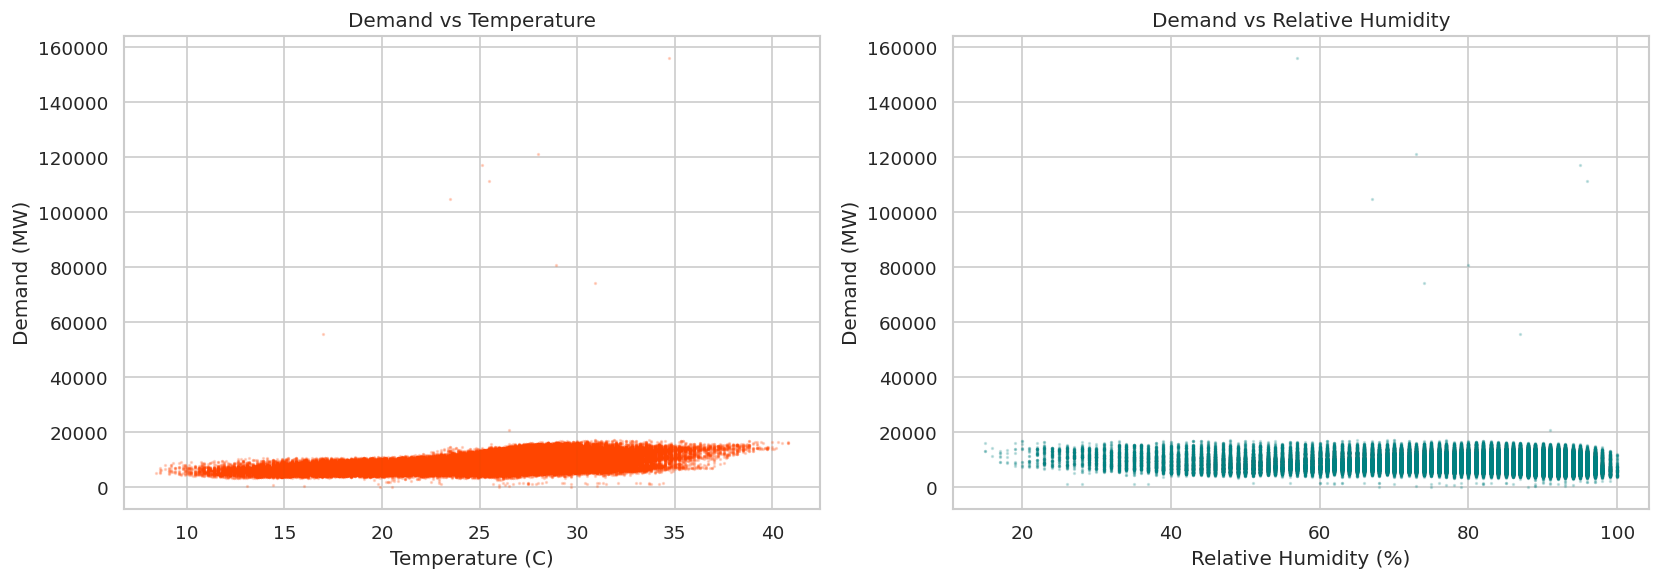

Pearson r -> Temperature vs Demand: 0.448
Pearson r -> Humidity vs Demand:    -0.088


In [16]:

# Prepare hourly weather subset matching PGCB range
weather_subset = weather[(weather['time'] >= pgcb_sorted['datetime'].min()) &
                         (weather['time'] <= pgcb_sorted['datetime'].max())].copy()
weather_subset = weather_subset.rename(columns={'time': 'datetime'})

# Merge on nearest hour
merged_preview = pd.merge_asof(
    pgcb_sorted.sort_values('datetime'),
    weather_subset[['datetime','temperature_2m','relative_humidity_2m']].sort_values('datetime'),
    on='datetime', direction='nearest', tolerance=pd.Timedelta('1h')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Demand vs Temperature
axes[0].scatter(merged_preview['temperature_2m'], merged_preview['demand_mw'], s=1, alpha=0.2, color='orangered')
axes[0].set_title('Demand vs Temperature')
axes[0].set_xlabel('Temperature (C)'); axes[0].set_ylabel('Demand (MW)')

# Demand vs Humidity
axes[1].scatter(merged_preview['relative_humidity_2m'], merged_preview['demand_mw'], s=1, alpha=0.2, color='teal')
axes[1].set_title('Demand vs Relative Humidity')
axes[1].set_xlabel('Relative Humidity (%)'); axes[1].set_ylabel('Demand (MW)')

plt.tight_layout(); plt.show()

r_temp = merged_preview[['temperature_2m','demand_mw']].dropna().corr().iloc[0,1]
r_hum  = merged_preview[['relative_humidity_2m','demand_mw']].dropna().corr().iloc[0,1]
print(f"Pearson r -> Temperature vs Demand: {r_temp:.3f}")
print(f"Pearson r -> Humidity vs Demand:    {r_hum:.3f}")


### 3.14 Correlation Heatmap of Merged Preview

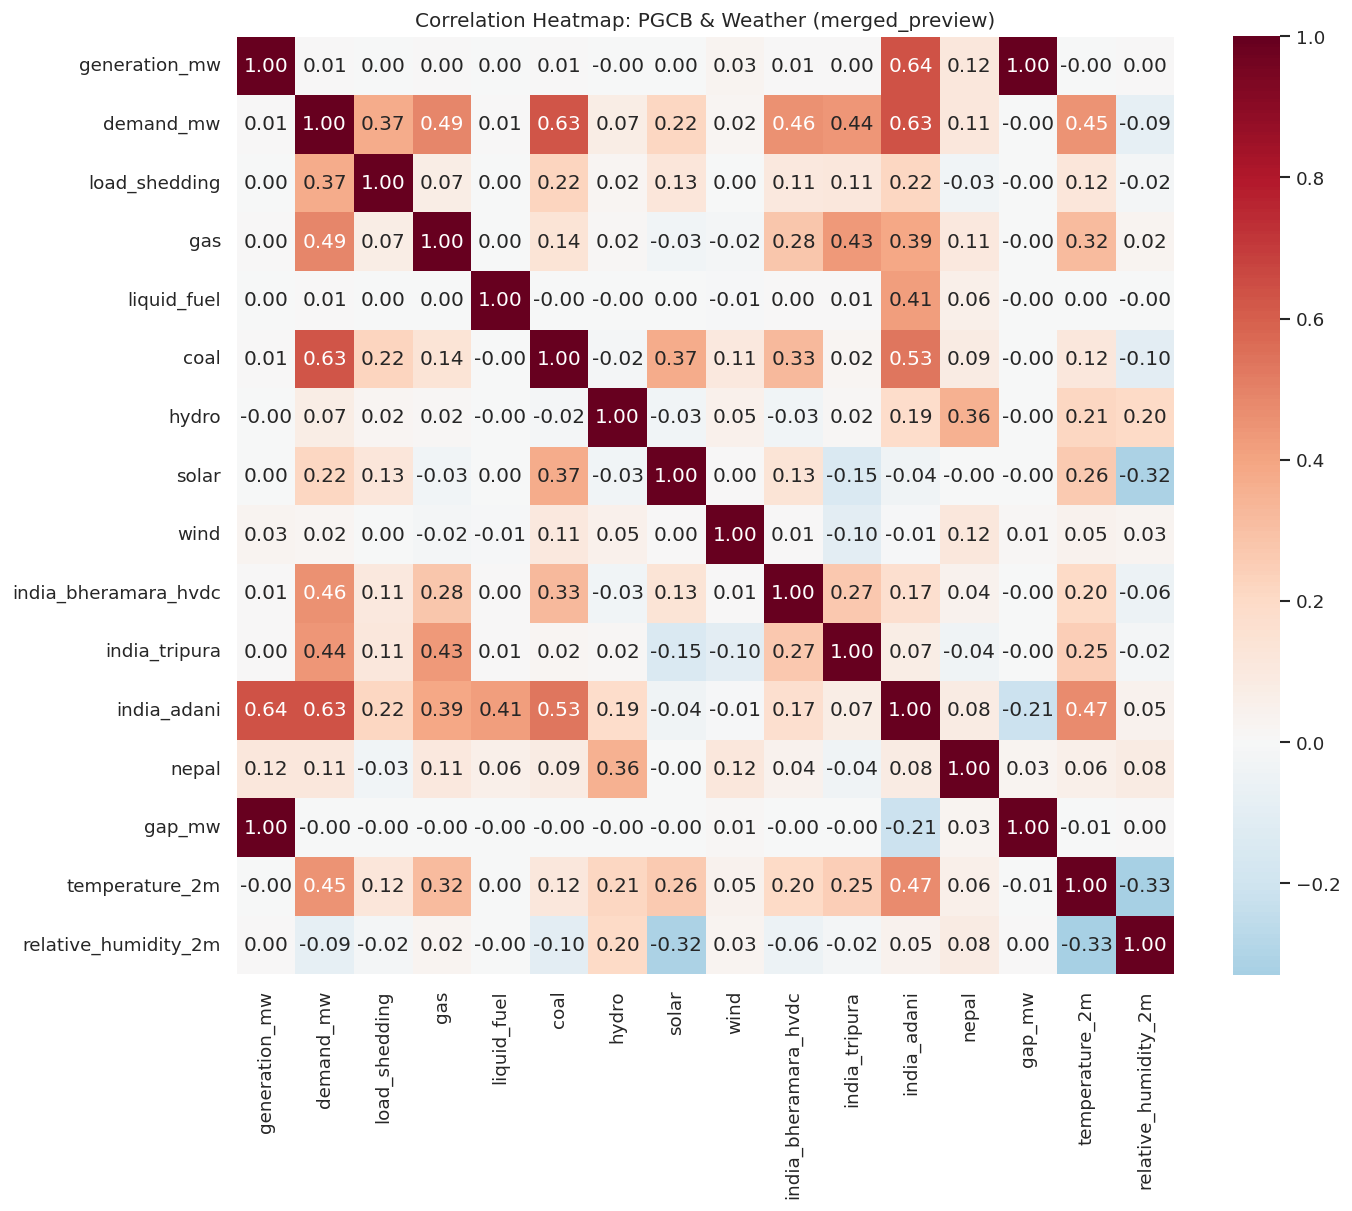

In [17]:

# Filter for numeric columns in the merged preview
numeric_merged = merged_preview.select_dtypes(include=[np.number])
corr_matrix = numeric_merged.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Correlation Heatmap: PGCB & Weather (merged_preview)')
plt.tight_layout()
plt.show()


## 4. Preprocessing

### 4.1 Drop Unusable Columns

In [18]:

drop_cols = ['remarks', 'india_adani', 'nepal', 'wind']
pgcb_clean = pgcb.drop(columns=drop_cols)
print(f"Dropped {drop_cols} -> remaining columns: {list(pgcb_clean.columns)}")
print(f"Shape: {pgcb_clean.shape}")


Dropped ['remarks', 'india_adani', 'nepal', 'wind'] -> remaining columns: ['datetime', 'generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'india_bheramara_hvdc', 'india_tripura']
Shape: (92650, 11)


### 4.2 Sort Chronologically & Resample to 1-Hour Mean

In [19]:

# Sort chronologically
pgcb_clean = pgcb_clean.sort_values('datetime').reset_index(drop=True)

# Set datetime as index and resample to 1H mean (handles duplicates + :30 rows)
pgcb_clean = pgcb_clean.set_index('datetime').resample('1h').mean()
pgcb_clean = pgcb_clean.dropna(how='all')  # drop hours with zero data

print(f"After 1H resample: {pgcb_clean.shape[0]:,} rows")
print(f"Date range: {pgcb_clean.index.min()} -> {pgcb_clean.index.max()}")
print(f"Frequency check -- inferred: {pd.infer_freq(pgcb_clean.index[:100])}")


After 1H resample: 88,050 rows
Date range: 2015-04-19 00:00:00 -> 2025-06-17 12:00:00
Frequency check -- inferred: None


### 4.3 Outlier Clipping & KNN Imputation

In [20]:

# Recompute IQR on the resampled data
Q1 = pgcb_clean['demand_mw'].quantile(0.25)
Q3 = pgcb_clean['demand_mw'].quantile(0.75)
IQR = Q3 - Q1
lower_b, upper_b = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

outlier_mask = (pgcb_clean['demand_mw'] < lower_b) | (pgcb_clean['demand_mw'] > upper_b)
n_outliers = outlier_mask.sum()
print(f"demand_mw outliers (1.5xIQR): {n_outliers} rows flagged -> replacing with NaN")
pgcb_clean.loc[outlier_mask, 'demand_mw'] = np.nan

# KNN impute all numeric columns (demand_mw outliers + solar gaps + any residual NaNs)
print(f"NaNs before KNN impute:\n{pgcb_clean.isnull().sum()[pgcb_clean.isnull().sum()>0]}")

imputer = KNNImputer(n_neighbors=5, weights='distance')
pgcb_imputed = pd.DataFrame(
    imputer.fit_transform(pgcb_clean),
    columns=pgcb_clean.columns,
    index=pgcb_clean.index
)
print(f"\nKNN imputation complete. Remaining NaNs: {pgcb_imputed.isnull().sum().sum()}")


demand_mw outliers (1.5xIQR): 87 rows flagged -> replacing with NaN
NaNs before KNN impute:
demand_mw       87
solar        20520
dtype: int64

KNN imputation complete. Remaining NaNs: 0


### 4.4 Weather â€” Filter, Align to Hourly, Drop Highly Correlated Features

In [21]:

# Filter weather to PGCB range (2015 onward)
weather_clean = weather[weather['time'] >= '2015-01-01'].copy()
weather_clean = weather_clean.rename(columns={'time': 'datetime'})

# Drop temporary columns added during EDA
for col_to_drop in ['month_period']:
    if col_to_drop in weather_clean.columns:
        weather_clean = weather_clean.drop(columns=[col_to_drop])

weather_clean = weather_clean.set_index('datetime')

# Already hourly -- verify
print(f"Weather filtered: {weather_clean.shape[0]:,} rows, {weather_clean.index.min()} -> {weather_clean.index.max()}")

# Drop highly correlated features (apparent_temperature ~ temperature_2m, soil_temp ~ temperature)
weather_corr = weather_clean.corr().abs()
print("\nHigh correlations with temperature_2m:")
if 'temperature_2m' in weather_corr.columns:
    print(weather_corr['temperature_2m'].sort_values(ascending=False).head(5))

# Drop apparent_temperature and soil_temperature_0_to_7cm (redundant with temperature_2m)
weather_clean = weather_clean.drop(columns=['apparent_temperature', 'soil_temperature_0_to_7cm'], errors='ignore')
print(f"\nWeather features kept: {list(weather_clean.columns)}")


Weather filtered: 98,544 rows, 2015-01-01 00:00:00 -> 2026-03-29 23:00:00

High correlations with temperature_2m:
temperature_2m               1.000000
soil_temperature_0_to_7cm    0.968733
apparent_temperature         0.965707
dew_point_2m                 0.667370
sunshine_duration            0.443736
Name: temperature_2m, dtype: float64

Weather features kept: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'dew_point_2m', 'wind_direction_10m', 'cloud_cover', 'sunshine_duration']


### 4.5 Economic Indicators â€” Select, Melt & Forward-Fill

In [22]:

# Select relevant indicators by keyword
keywords = ['GDP per capita', 'Electric power consumption', 'Energy use',
            'Population, total', 'Urban population', 'Industry']
mask = econ['Indicator Name'].str.contains('|'.join(keywords), case=False, na=False)
econ_sel = econ[mask].copy()
print(f"Selected {len(econ_sel)} economic indicators")

# Melt from wide to long format
year_cols = [c for c in econ_sel.columns if c.isdigit()]
econ_long = econ_sel.melt(
    id_vars=['Indicator Name', 'Indicator Code'],
    value_vars=year_cols,
    var_name='year', value_name='value'
)
econ_long['year'] = econ_long['year'].astype(int)

# Pivot so each indicator becomes a column
econ_pivot = econ_long.pivot_table(index='year', columns='Indicator Name', values='value')
econ_pivot = econ_pivot.sort_index()

# Forward fill missing years then backward fill any leading NaNs
econ_pivot = econ_pivot.ffill().bfill()

# Keep only 2015-2025
econ_pivot = econ_pivot.loc[2015:2025]
print(f"Economic pivot shape: {econ_pivot.shape}")
print(f"Years: {econ_pivot.index.min()} -> {econ_pivot.index.max()}")
print(f"Remaining NaNs: {econ_pivot.isnull().sum().sum()}")


Selected 47 economic indicators
Economic pivot shape: (11, 47)
Years: 2015 -> 2025
Remaining NaNs: 0


### 4.6 Merge PGCB + Weather + Economic Data

In [23]:

# Merge PGCB (hourly) + Weather (hourly) on datetime index
df = pgcb_imputed.join(weather_clean, how='left')
print(f"After PGCB + Weather merge: {df.shape}")

# Add year column for economic merge (index is DatetimeIndex)
df['year'] = df.index.year

# Shorten economic column names to avoid issues
econ_col_names = list(econ_pivot.columns)
econ_pivot.columns = ['econ_' + str(i) for i in range(len(econ_pivot.columns))]
econ_cols_map = {f'econ_{i}': name for i, name in enumerate(econ_col_names)}
print(f"Economic features added: {len(econ_pivot.columns)}")

# Merge economic by year -- use map-based approach to preserve DatetimeIndex
for col in econ_pivot.columns:
    df[col] = df['year'].map(econ_pivot[col])

df = df.drop(columns=['year'])

print(f"Final merged shape: {df.shape}")
print(f"Columns: {list(df.columns)}")


After PGCB + Weather merge: (88050, 17)
Economic features added: 47
Final merged shape: (88050, 64)
Columns: ['generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'india_bheramara_hvdc', 'india_tripura', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'dew_point_2m', 'wind_direction_10m', 'cloud_cover', 'sunshine_duration', 'econ_0', 'econ_1', 'econ_2', 'econ_3', 'econ_4', 'econ_5', 'econ_6', 'econ_7', 'econ_8', 'econ_9', 'econ_10', 'econ_11', 'econ_12', 'econ_13', 'econ_14', 'econ_15', 'econ_16', 'econ_17', 'econ_18', 'econ_19', 'econ_20', 'econ_21', 'econ_22', 'econ_23', 'econ_24', 'econ_25', 'econ_26', 'econ_27', 'econ_28', 'econ_29', 'econ_30', 'econ_31', 'econ_32', 'econ_33', 'econ_34', 'econ_35', 'econ_36', 'econ_37', 'econ_38', 'econ_39', 'econ_40', 'econ_41', 'econ_42', 'econ_43', 'econ_44', 'econ_45', 'econ_46']


### 4.7 Final Missing Value Check & Cleanup

In [24]:

missing_final = df.isnull().sum()
missing_final = missing_final[missing_final > 0]

if len(missing_final) > 0:
    print("Remaining NaNs after merge:")
    print(missing_final)
    # Forward-fill then backward-fill small residual gaps from weather join edges
    df = df.ffill().bfill()
    print(f"\nAfter ffill/bfill -- NaNs remaining: {df.isnull().sum().sum()}")
else:
    print("No missing values -- dataframe is clean.")

print(f"\nFinal clean dataframe: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Date range: {df.index.min()} -> {df.index.max()}")
print(f"dtypes:\n{df.dtypes}")


No missing values -- dataframe is clean.

Final clean dataframe: 88,050 rows x 64 cols
Date range: 2015-04-19 00:00:00 -> 2025-06-17 12:00:00
dtypes:
generation_mw    float64
demand_mw        float64
load_shedding    float64
gas              float64
liquid_fuel      float64
                  ...   
econ_42          float64
econ_43          float64
econ_44          float64
econ_45          float64
econ_46          float64
Length: 64, dtype: object


## 5. Feature Engineering

### 5.1 Calendar Features

In [25]:

df['hour']           = df.index.hour
df['dayofweek']      = df.index.dayofweek
df['month']          = df.index.month
df['quarter']        = df.index.quarter
df['is_weekend']     = df['dayofweek'].isin([4, 5]).astype(int)   # Bangladesh: Fri + Sat
df['is_day_peak']    = df['hour'].between(12, 15).astype(int)     # 12-15h
df['is_evening_peak']= df['hour'].between(18, 21).astype(int)     # 18-21h

# Cyclical encoding for hour and month (helps tree models capture periodicity)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

print("Calendar features added:")
print(df[['hour','dayofweek','month','quarter','is_weekend','is_day_peak','is_evening_peak']].head(10))


Calendar features added:
                     hour  dayofweek  month  quarter  is_weekend  is_day_peak  \
datetime                                                                        
2015-04-19 00:00:00     0          6      4        2           0            0   
2015-04-19 01:00:00     1          6      4        2           0            0   
2015-04-19 02:00:00     2          6      4        2           0            0   
2015-04-19 03:00:00     3          6      4        2           0            0   
2015-04-19 04:00:00     4          6      4        2           0            0   
2015-04-19 05:00:00     5          6      4        2           0            0   
2015-04-19 06:00:00     6          6      4        2           0            0   
2015-04-19 07:00:00     7          6      4        2           0            0   
2015-04-19 08:00:00     8          6      4        2           0            0   
2015-04-19 09:00:00     9          6      4        2           0            0   

  

### 5.2 Lag Features

In [26]:

lag_hours = [1, 2, 3, 24, 48, 168]
for lag in lag_hours:
    df[f'demand_lag_{lag}h'] = df['demand_mw'].shift(lag)

print(f"Lag features added: {[f'demand_lag_{h}h' for h in lag_hours]}")
print(f"NaNs introduced by lags (first 168 rows): {df[[f'demand_lag_{h}h' for h in lag_hours]].isnull().sum().to_dict()}")


Lag features added: ['demand_lag_1h', 'demand_lag_2h', 'demand_lag_3h', 'demand_lag_24h', 'demand_lag_48h', 'demand_lag_168h']
NaNs introduced by lags (first 168 rows): {'demand_lag_1h': 1, 'demand_lag_2h': 2, 'demand_lag_3h': 3, 'demand_lag_24h': 24, 'demand_lag_48h': 48, 'demand_lag_168h': 168}


### 5.3 Rolling Aggregate Features

In [27]:

rolling_windows = [3, 6, 12, 24]
for w in rolling_windows:
    df[f'demand_rmean_{w}h'] = df['demand_mw'].shift(1).rolling(w, min_periods=1).mean()

# Rolling std 24h
df['demand_rstd_24h'] = df['demand_mw'].shift(1).rolling(24, min_periods=1).std()

# Demand rate of change
df['demand_diff_1h'] = df['demand_mw'].shift(1) - df['demand_mw'].shift(2)

print(f"Rolling features added: rmean {rolling_windows} + rstd 24h + diff_1h")
print(df[[f'demand_rmean_{w}h' for w in rolling_windows] + ['demand_rstd_24h']].describe().T)


Rolling features added: rmean [3, 6, 12, 24] + rstd 24h + diff_1h
                    count         mean          std          min          25%  \
demand_rmean_3h   88049.0  8777.511930  2583.326101  1799.000000  6793.000000   
demand_rmean_6h   88049.0  8777.373896  2545.442338  1920.166667  6818.166667   
demand_rmean_12h  88049.0  8777.085745  2478.219822  2464.500000  6858.000000   
demand_rmean_24h  88049.0  8776.421710  2415.638865  3653.687500  6875.479167   
demand_rstd_24h   88048.0   974.924808   263.778009   214.419387   841.120029   

                          50%           75%           max  
demand_rmean_3h   8378.333333  10574.000000  16291.666667  
demand_rmean_6h   8365.833333  10557.333333  16250.000000  
demand_rmean_12h  8344.125000  10509.250000  16076.499677  
demand_rmean_24h  8324.395833  10494.125000  15848.064320  
demand_rstd_24h    964.647326   1073.415126   3625.416246  


### 5.4 Define Target, Train/Test Split & Leakage Verification

In [28]:

# Target: next hour's demand (shift -1)
df['target'] = df['demand_mw'].shift(-1)

# Drop rows with NaN target or NaN lag features
df = df.dropna(subset=['target'] + [f'demand_lag_{h}h' for h in lag_hours])
print(f"After dropping NaN rows: {df.shape[0]:,} rows")

# â”€â”€ Leaky columns (all measured at time t, unknown at forecast time) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# generation_mw  â‰ˆ demand_mw at t  â†’  almost-perfect proxy for the target
# load_shedding, gas, liquid_fuel, coal, hydro, solar,
# india_bheramara_hvdc, india_tripura  â†’  operational readings only known at t
LEAKY_COLS = [
    'generation_mw',          # biggest leaker: essentially = demand_mw
    'load_shedding',          # operational dispatch variable at t
    'gas', 'liquid_fuel', 'coal', 'hydro', 'solar',   # generation-mix at t
    'india_bheramara_hvdc', 'india_tripura',            # imports at t
]

# Exclude target, demand_mw itself, and all leaky operational columns
feature_cols = [
    c for c in df.columns
    if c not in ['target', 'demand_mw'] + LEAKY_COLS
]

print(f"\nDropped leaky features: {[c for c in LEAKY_COLS if c in df.columns]}")
print(f"Remaining features: {len(feature_cols)}")

# Chronological train/test split at 2024 boundary
train = df[df.index < '2024-01-01']
test  = df[df.index >= '2024-01-01']

X_train, y_train = train[feature_cols], train['target']
X_test,  y_test  = test[feature_cols],  test['target']

print(f"\nTrain: {X_train.shape[0]:,} rows ({train.index.min().date()} -> {train.index.max().date()})")
print(f"Test:  {X_test.shape[0]:,} rows  ({test.index.min().date()} -> {test.index.max().date()})")
print(f"Features: {len(feature_cols)}")
print(f"Target stats -- Train mean={y_train.mean():,.0f} MW, Test mean={y_test.mean():,.0f} MW")

# Leakage check: ensure no test dates appear in train
assert train.index.max() < test.index.min(), "DATA LEAKAGE DETECTED!"
print("Zero leakage confirmed -- train ends before test starts.")

# Normalize features using StandardScaler (fit on train only)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=feature_cols, index=X_test.index)
print("StandardScaler fitted on train only, applied to both splits.")

After dropping NaN rows: 87,881 rows

Dropped leaky features: ['generation_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'india_bheramara_hvdc', 'india_tripura']
Remaining features: 77

Train: 75,092 rows (2015-04-28 -> 2023-12-31)
Test:  12,789 rows  (2024-01-01 -> 2025-06-17)
Features: 77
Target stats -- Train mean=8,330 MW, Test mean=11,452 MW
Zero leakage confirmed -- train ends before test starts.
StandardScaler fitted on train only, applied to both splits.


## 6. Modelling

### 6.1 Random Forest Baseline

In [29]:

rf = RandomForestRegressor(n_estimators=300, max_depth=20, min_samples_leaf=5,
                           n_jobs=-1, random_state=42)
rf.fit(X_train_scaled, y_train)

rf_pred = rf.predict(X_test_scaled)
rf_mape = mean_absolute_percentage_error(y_test, rf_pred) * 100
print(f"Random Forest -- Test MAPE: {rf_mape:.2f}%")


Random Forest -- Test MAPE: 3.29%


### 6.2 XGBoost

In [30]:

xgb_model = xgb.XGBRegressor(
    n_estimators=800, max_depth=8, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
    tree_method='hist', random_state=42, n_jobs=-1
)
xgb_model.fit(X_train_scaled, y_train,
              eval_set=[(X_test_scaled, y_test)],
              verbose=100)

xgb_pred = xgb_model.predict(X_test_scaled)
xgb_mape = mean_absolute_percentage_error(y_test, xgb_pred) * 100
print(f"\nXGBoost -- Test MAPE: {xgb_mape:.2f}%")


[0]	validation_0-rmse:3801.46533
[100]	validation_0-rmse:623.73319
[200]	validation_0-rmse:533.92746
[300]	validation_0-rmse:529.67965
[400]	validation_0-rmse:529.44554
[500]	validation_0-rmse:532.37233
[600]	validation_0-rmse:536.05866
[700]	validation_0-rmse:538.80592
[799]	validation_0-rmse:542.58932

XGBoost -- Test MAPE: 3.30%


### 6.3 LightGBM

In [31]:

lgb_model = lgb.LGBMRegressor(
    n_estimators=800, max_depth=10, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
    min_child_samples=20, reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbose=-1
)
lgb_model.fit(X_train_scaled, y_train,
              eval_set=[(X_test_scaled, y_test)])

lgb_pred = lgb_model.predict(X_test_scaled)
lgb_mape = mean_absolute_percentage_error(y_test, lgb_pred) * 100
print(f"LightGBM -- Test MAPE: {lgb_mape:.2f}%")


LightGBM -- Test MAPE: 3.19%


### 6.4 Weighted Ensemble

In [32]:

ensemble_pred = 0.2 * rf_pred + 0.4 * xgb_pred + 0.4 * lgb_pred
ensemble_mape = mean_absolute_percentage_error(y_test, ensemble_pred) * 100
print(f"Ensemble (0.2*RF + 0.4*XGB + 0.4*LGB) -- Test MAPE: {ensemble_mape:.2f}%")


Ensemble (0.2*RF + 0.4*XGB + 0.4*LGB) -- Test MAPE: 3.15%


## 7. Model Evaluation

### 7.1 Model Comparison â€” MAPE Scores


     MODEL COMPARISON -- Test MAPE
        Model  MAPE (%)
     Ensemble  3.145467
     LightGBM  3.187080
Random Forest  3.292742
      XGBoost  3.296182

Best Model: Ensemble with MAPE = 3.15%


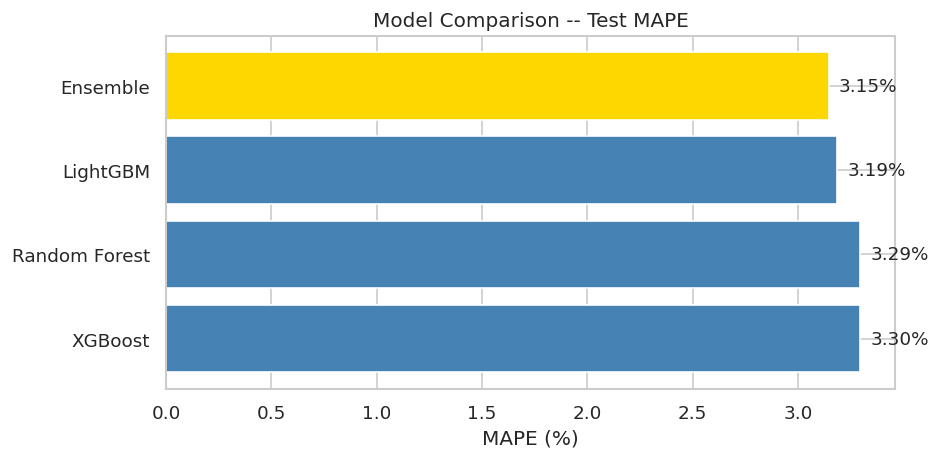

In [33]:

results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'LightGBM', 'Ensemble'],
    'MAPE (%)': [rf_mape, xgb_mape, lgb_mape, ensemble_mape]
}).sort_values('MAPE (%)')

print("\n" + "="*40)
print("     MODEL COMPARISON -- Test MAPE")
print("="*40)
print(results.to_string(index=False))

best_name = results.iloc[0]['Model']
best_mape = results.iloc[0]['MAPE (%)']
print(f"\nBest Model: {best_name} with MAPE = {best_mape:.2f}%")

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['gold' if m == best_name else 'steelblue' for m in results['Model']]
ax.barh(results['Model'], results['MAPE (%)'], color=colors, edgecolor='white')
for i, v in enumerate(results['MAPE (%)']):
    ax.text(v + 0.05, i, f'{v:.2f}%', va='center', fontsize=11)
ax.set_xlabel('MAPE (%)'); ax.set_title('Model Comparison -- Test MAPE')
ax.invert_yaxis()
plt.tight_layout(); plt.show()


### 7.2 Top-20 Feature Importances

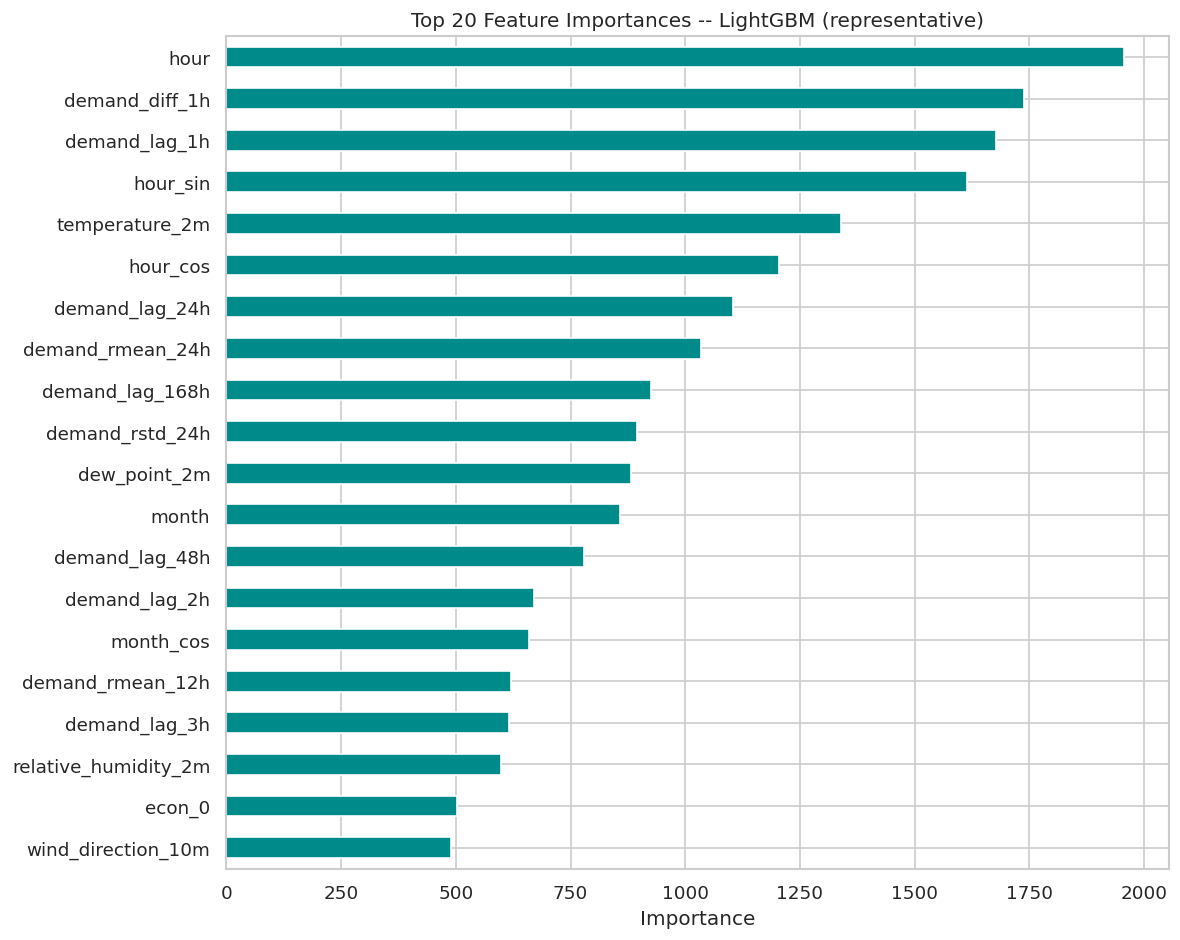

In [34]:

best_models = {'Random Forest': rf, 'XGBoost': xgb_model, 'LightGBM': lgb_model}
if best_name in best_models:
    best_model = best_models[best_name]
else:
        best_model = lgb_model

if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
    top20 = imp.tail(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    top20.plot(kind='barh', ax=ax, color='darkcyan', edgecolor='white')
    ax.set_title(f'Top 20 Feature Importances -- {best_name if best_name in best_models else "LightGBM (representative)"}')
    ax.set_xlabel('Importance')
    plt.tight_layout(); plt.show()


### 7.3 Predicted vs Actual Demand â€” Test Set

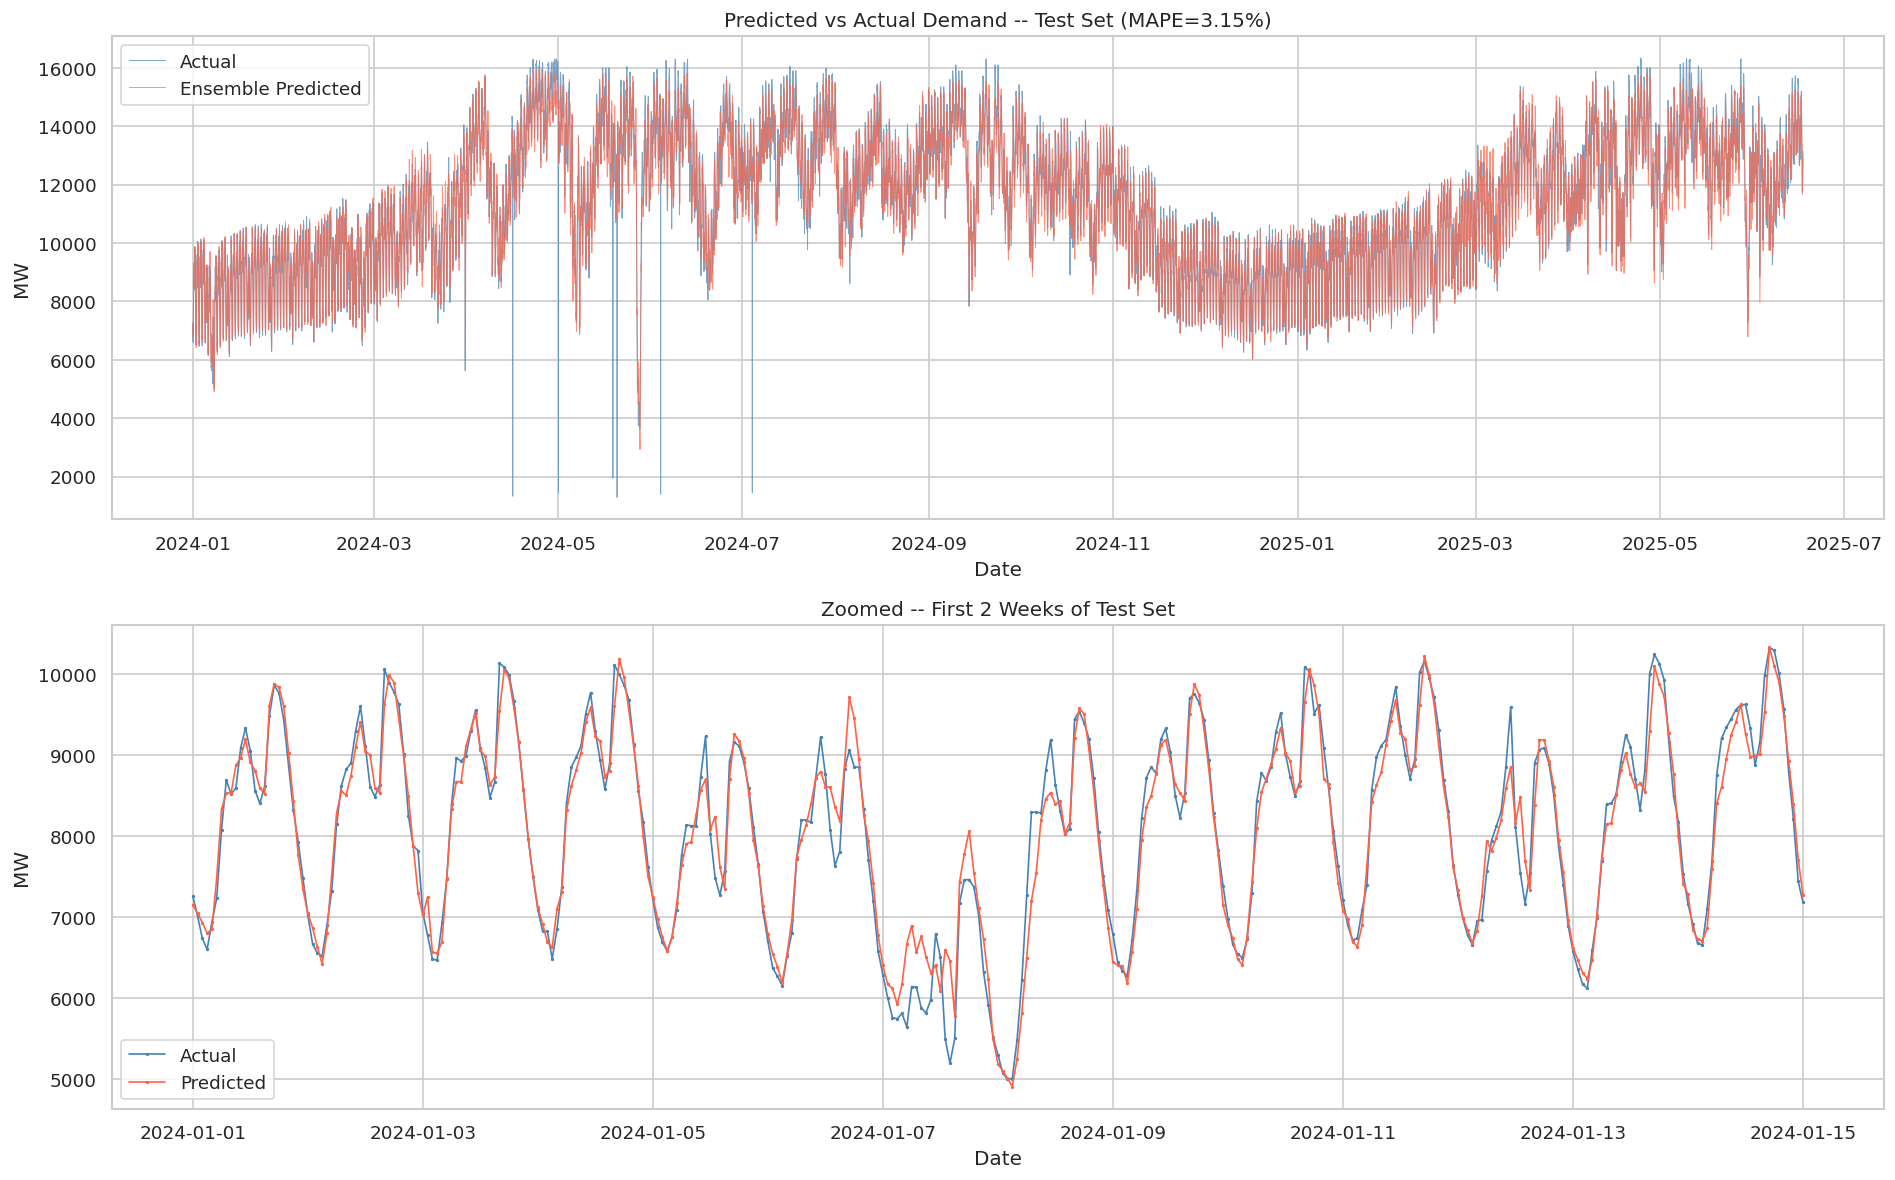


Pipeline complete. Best model: Ensemble
  MAPE: 3.15%
  MAE:  323 MW
  RMSE: 504 MW


In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

best_preds = {'Random Forest': rf_pred, 'XGBoost': xgb_pred, 'LightGBM': lgb_pred, 'Ensemble': ensemble_pred}
pred = best_preds[best_name]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Full test period
axes[0].plot(y_test.index, y_test.values, lw=0.6, alpha=0.7, label='Actual', color='steelblue')
axes[0].plot(y_test.index, pred, lw=0.6, alpha=0.7, label=f'{best_name} Predicted', color='tomato')
axes[0].set_title(f'Predicted vs Actual Demand -- Test Set (MAPE={best_mape:.2f}%)')
axes[0].set_ylabel('MW'); axes[0].legend(); axes[0].set_xlabel('Date')

# Zoomed: first 2 weeks of test set
zoom_end = y_test.index.min() + pd.Timedelta(days=14)
mask_zoom = y_test.index <= zoom_end
axes[1].plot(y_test.index[mask_zoom], y_test.values[mask_zoom], lw=1, marker='.', markersize=2,
             label='Actual', color='steelblue')
axes[1].plot(y_test.index[mask_zoom], pred[mask_zoom], lw=1, marker='.', markersize=2,
             label='Predicted', color='tomato')
axes[1].set_title('Zoomed -- First 2 Weeks of Test Set')
axes[1].set_ylabel('MW'); axes[1].legend(); axes[1].set_xlabel('Date')

plt.tight_layout(); plt.show()

# Additional metrics
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
print(f"\nPipeline complete. Best model: {best_name}")
print(f"  MAPE: {best_mape:.2f}%")
print(f"  MAE:  {mae:,.0f} MW")
print(f"  RMSE: {rmse:,.0f} MW")